# Neutron Star Magnetospheric Ray Tracing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
from dataclasses import dataclass, field
from matplotlib.colors import LinearSegmentedColormap
from typing import Callable
from tqdm.auto import tqdm
import pathlib
# import h5py
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe

from matplotlib import rc
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
matplotlib.rcParams.update({'font.size': 12})
params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

pa_cmap = LinearSegmentedColormap.from_list('pa_cyclic', [
    (0.00, 'white'),      # PA = -90
    (0.25, 'steelblue'),  # PA = -45
    (0.50, 'black'),      # PA =   0
    (0.75, 'firebrick'),  # PA = +45
    (1.00, 'white'),      # PA = +90  (same as -90 -- physically correct wrap)
])

## Sky maps

Bins escaped rays onto a (rotation phase, `cos θ`) grid and accumulates Stokes `I`, `Q`, `U`, and the X-mode fraction. The polarization angle reference is set by the *frozen* magnetic field direction at each ray's last coupled point (`Bfrz`), with O-mode PA parallel to the projected field and X-mode perpendicular — the standard convention in pulsar polarimetry.

In [8]:
def load_dict_from_hdf5(filename):
    out = {}
    with h5py.File(filename, "r") as h5f:
        for name in h5f.keys():
            out[name] = h5f[name][...]   # read fully into memory
    return out

In [9]:
res = load_dict_from_hdf5("res_out.h5")

In [10]:
def make_maps(res, nph=720, nth=360):
    """Bin escaped rays onto a (phase/azimuth, cos-theta) sky grid and accumulate Stokes I, Q, U and X-mode fraction, with PA set by projected B at the freeze point (O parallel, X perpendicular).

    Args:
        res : dict -- output dictionary of propagate() (uses keys x, k, isO, Bfrz, escaped).
        nph : int  -- number of azimuthal (rotation phase) bins (default 120).
        nth : int  -- number of cos(theta) (line-of-sight colatitude) bins (default 60).

    Returns:
        dict with keys:
            I, Q, U : (nth, nph) binned Stokes maps,
            Xf      : (nth, nph) binned X-mode photon counts,
            phie    : (nph+1,) azimuth bin edges [rad],
            cthe    : (nth+1,) cos(theta) bin edges.
    """
    sel  = res['escaped']
    k    = res['k'][sel]; isO = res['isO'][sel]; B = res['Bfrz'][sel]
    khat = k / np.linalg.norm(k, axis=1, keepdims=True)
    cth  = khat[:, 2]
    phi  = np.mod(np.arctan2(khat[:, 1], khat[:, 0]), 2*np.pi)

    # sky basis perpendicular to khat (reference: celestial north = z)
    zax = np.array([0.0, 0.0, 1.0])
    e1  = np.cross(np.broadcast_to(zax, khat.shape), khat)
    bad = np.linalg.norm(e1, axis=1) < 1e-8
    e1[bad] = np.cross([1.0, 0, 0], khat[bad])
    e1 /= np.linalg.norm(e1, axis=1, keepdims=True)
    e2  = np.cross(khat, e1)

    psiB = np.arctan2(np.sum(B*e2, axis=1), np.sum(B*e1, axis=1))
    psi  = np.where(isO, psiB, psiB + np.pi/2)     # O || B_proj, X perp
    Q, U = np.cos(2*psi), np.sin(2*psi)

    bins = [np.linspace(0, 2*np.pi, nph+1), np.linspace(-1, 1, nth+1)]
    H  = lambda w: np.histogram2d(phi, cth, bins=bins, weights=w)[0].T
    I  = H(np.ones(len(phi)))
    return dict(I=I, Q=H(Q), U=H(U), Xf=H((~isO).astype(float)),
                phie=bins[0], cthe=bins[1])

def plot_maps(mp):
    """Plot the four all-sky maps (intensity, linear polarization fraction, polarization angle, X-mode fraction) from a make_maps() output.

    Args:
        mp : dict -- output dictionary of make_maps() (uses keys I, Q, U, Xf).

    Returns:
        (L, PA, Xf) : (nth, nph) arrays -- linear pol. fraction L/I, polarization angle [deg], and X-mode fraction, for further use.
    """
    I = mp['I'].copy(); I[I == 0] = np.nan
    L  = np.sqrt(mp['Q']**2 + mp['U']**2) / I
    PA = 0.5*np.rad2deg(np.arctan2(mp['U'], mp['Q']))
    Xf = mp['Xf'] / I
    ext = [0, 360, -1, 1]
    fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
    for a, dat, ttl, cm in zip(ax.flat,
            [I, L, PA, Xf],
            ['Intensity', 'Linear pol. fraction L/I', 'PA [deg]', 'X-mode fraction'],
            ['viridis', 'magma', 'twilight', 'coolwarm']):
        im = a.imshow(dat, origin='lower', extent=ext, aspect='auto', cmap=cm)
        a.set_title(ttl); fig.colorbar(im, ax=a)
    for a in ax[1]: a.set_xlabel('phase / azimuth [deg]')
    for a in ax[:, 0]: a.set_ylabel(r'$\cos\theta$ (line of sight)')
    plt.tight_layout(); plt.show()
    return L, PA, Xf

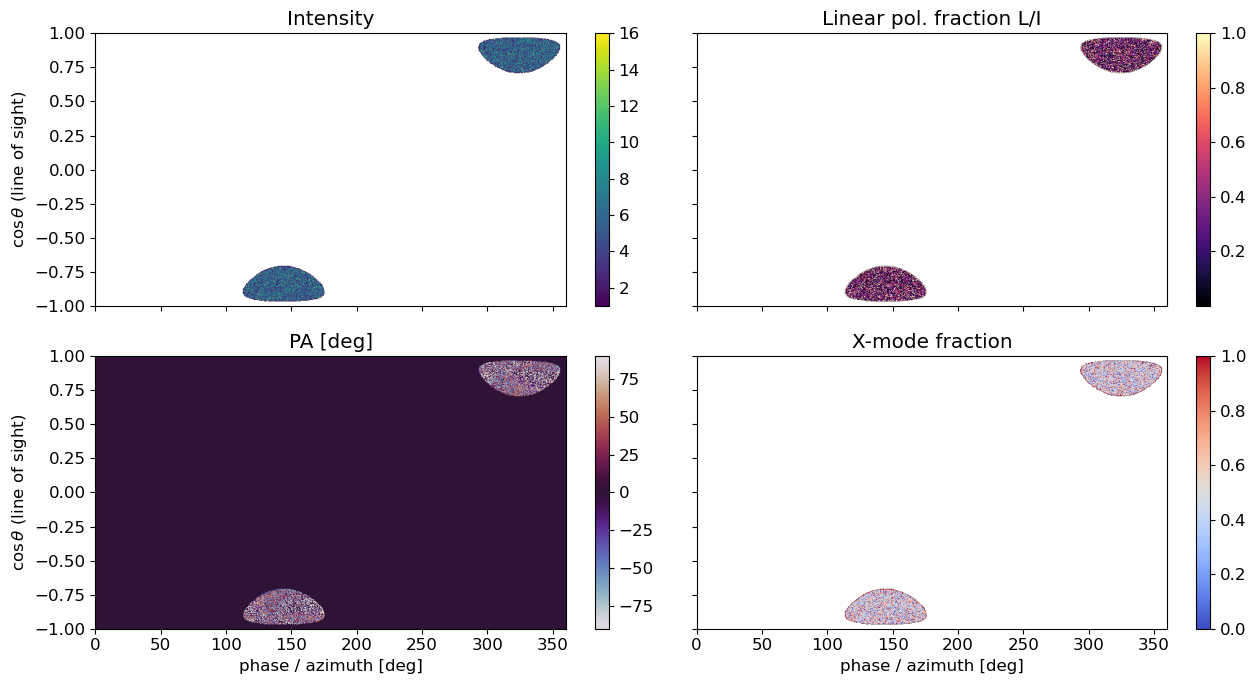

In [11]:
maps = make_maps(res)
L, PA, Xf = plot_maps(maps)

## Single-observer pulse profiles

Extracts a fixed-`ζ` (viewing angle) slice through the sky maps, producing the intensity, linear polarization fraction, PA-swing, and X-mode-fraction profiles a real observer would see as the star rotates — directly comparable to single-pulse or folded-profile polarimetric data.

In [12]:
def pulse_profile(mp, zeta_deg):
    """Extract and plot pulse profiles (I, L/I, PA, X-fraction vs. rotation phase) for an observer at a fixed viewing angle by slicing one row of the sky maps.

    Args:
        mp       : dict  -- output dictionary of make_maps() (uses keys I, Q, U, Xf, phie, cthe).
        zeta_deg : float -- observer's viewing angle zeta in degrees, measured from the rotation (z) axis.

    Returns:
        None -- displays a 4-panel matplotlib figure.
    """
    cz  = np.cos(np.deg2rad(zeta_deg))
    row = np.searchsorted(mp['cthe'], cz) - 1
    ph  = np.rad2deg(0.5*(mp['phie'][:-1] + mp['phie'][1:]))
    I   = mp['I'][row];  I_s = np.where(I > 0, I, np.nan)
    Lp  = np.sqrt(mp['Q'][row]**2 + mp['U'][row]**2)/I_s
    PAp = 0.5*np.rad2deg(np.arctan2(mp['U'][row], mp['Q'][row]))
    Xfp = mp['Xf'][row]/I_s

    fig, ax = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
    ax[0].plot(ph, I);   ax[0].set_ylabel('I')
    ax[1].plot(ph, Lp);  ax[1].set_ylabel('L/I'); ax[1].set_ylim(0, 1.05)
    ax[2].plot(ph, PAp, '.'); ax[2].set_ylabel('PA [deg]')
    ax[3].plot(ph, Xfp); ax[3].set_ylabel('X fraction'); ax[3].set_ylim(0, 1.05)
    ax[3].set_xlabel('rotation phase [deg]')
    # fig.suptitle(f'Observer at zeta = {zeta_deg} deg (chi = {np.rad2deg(M.chi):.0f} deg)')
    plt.tight_layout(); plt.show()

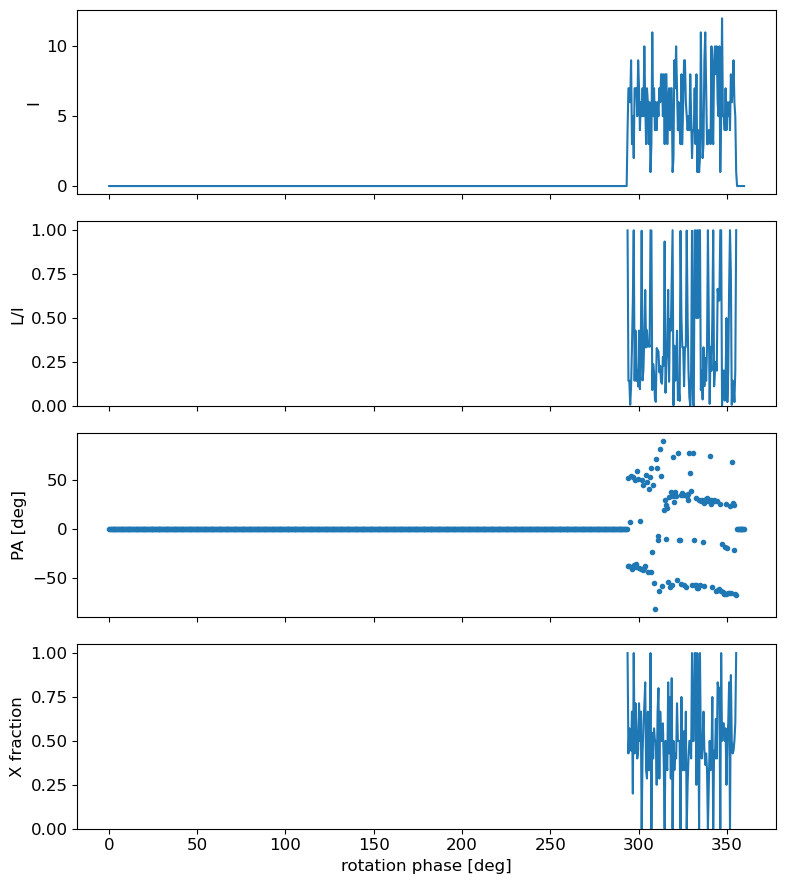

In [13]:
pulse_profile(maps, zeta_deg=25)

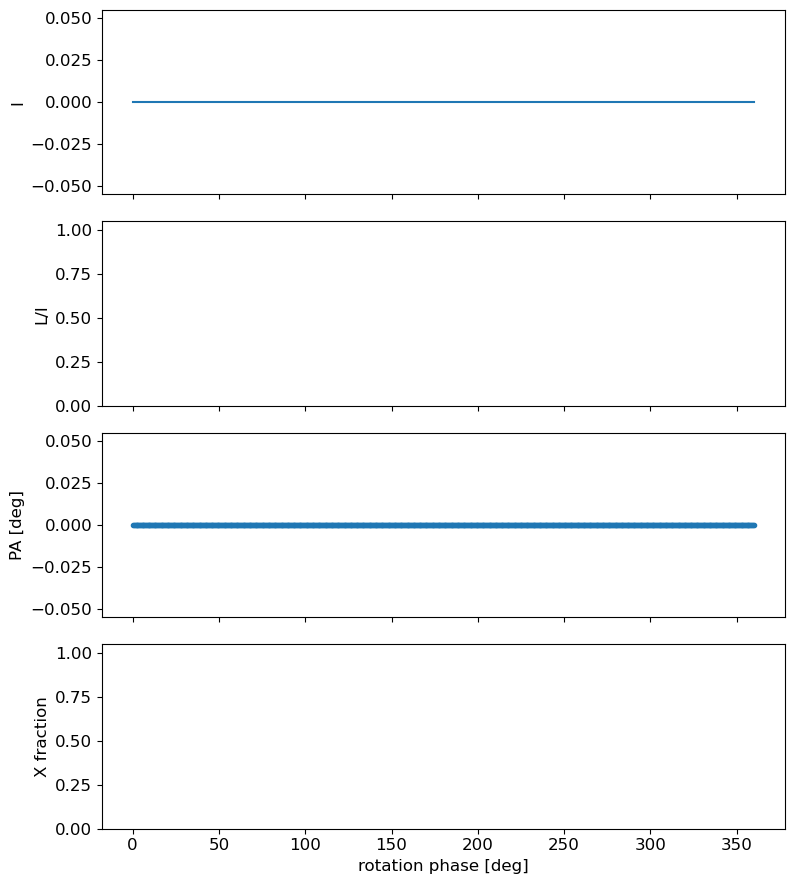

In [14]:
pulse_profile(maps, zeta_deg=5)

In [15]:
res1 = load_dict_from_hdf5("res_out.h5")
res2 = load_dict_from_hdf5("res_out_05.h5")

nph, nth = 200, 200
bins = [np.linspace(0, 2*np.pi, nph+1), np.linspace(-1, 1, nth+1)]
ext = [0, 360, -1, 1]
 
PAs, Xfs = [], []
for res in (res1, res2):
    sel  = res['escaped']
    k    = res['k'][sel]; isO = res['isO'][sel]; B = res['Bfrz'][sel]
    khat = k / np.linalg.norm(k, axis=1, keepdims=True)
    cth  = khat[:, 2]
    phi  = np.mod(np.arctan2(khat[:, 1], khat[:, 0]), 2*np.pi)
 
    zax = np.array([0.0, 0.0, 1.0])
    e1  = np.cross(np.broadcast_to(zax, khat.shape), khat)
    bad = np.linalg.norm(e1, axis=1) < 1e-8
    e1[bad] = np.cross([1.0, 0, 0], khat[bad])
    e1 /= np.linalg.norm(e1, axis=1, keepdims=True)
    e2  = np.cross(khat, e1)
 
    psiB = np.arctan2(np.sum(B*e2, axis=1), np.sum(B*e1, axis=1))
    psi  = np.where(isO, psiB, psiB + np.pi/2)
    Q, U = np.cos(2*psi), np.sin(2*psi)
 
    H = lambda w: np.histogram2d(phi, cth, bins=bins, weights=w)[0].T
    I = H(np.ones(len(phi)))
    I[I == 0] = np.nan
 
    PAs.append(0.5 * np.rad2deg(np.arctan2(H(U), H(Q))))
    Xfs.append(H((~isO).astype(float)) / I)
 
xf_vmax = np.nanmax([np.nanmax(x) for x in Xfs])
 
# ---- figure geometry, all in inches, computed by hand so panels are
#      EXACTLY square -- not delegated to an automatic layout engine ----
panel      = 3.0     # each panel is panel x panel inches, exactly
h_gap      = 0.12    # gap between the two case columns
v_gap      = 0.12    # gap between the PA row and the Xf row
left_marg  = 0.55    # room for y tick labels + ylabel
bot_marg   = 0.5     # room for x tick labels + xlabel
top_marg   = 0.05
cbar_gap   = 0.12    # gap between right panel and its colorbar
cbar_w     = 0.18
cbar_label = 0.7     # room for colorbar tick labels + label
 
fig_w = left_marg + 2*panel + h_gap + cbar_gap + cbar_w + cbar_label
fig_h = bot_marg + 2*panel + v_gap + top_marg
 
fig = plt.figure(figsize=(fig_w, fig_h), dpi=300)

def add_panel(row, col):
    x0 = left_marg + col*(panel + h_gap)
    y0 = bot_marg + (1-row)*(panel + v_gap)     # row 0 = top
    return fig.add_axes([x0/fig_w, y0/fig_h, panel/fig_w, panel/fig_h])
 
def add_cbar(row):
    x0 = left_marg + 2*panel + h_gap + cbar_gap
    y0 = bot_marg + (1-row)*(panel + v_gap)
    return fig.add_axes([x0/fig_w, y0/fig_h, cbar_w/fig_w, panel/fig_h])

def set_bad_color(cmap, color):
    cmap = plt.get_cmap(cmap).copy() if isinstance(cmap, str) else cmap.copy()
    cmap.set_bad(color)
    return cmap

pa_cmap_masked = set_bad_color(pa_cmap, 'white')
xf_cmap_masked = set_bad_color('seismic', 'white')

PAs_masked = [np.ma.masked_where((PAs[c] == 0) | np.isnan(PAs[c]), PAs[c]) for c in range(2)]
Xfs_masked = [np.ma.masked_where((Xfs[c] == 0) | np.isnan(Xfs[c]), Xfs[c]) for c in range(2)]

row_specs = [
    (PAs_masked, 'PA [deg]',        pa_cmap_masked, -90.0, 90.0),
    (Xfs_masked, 'X-Mode Fraction', xf_cmap_masked,  0.0, xf_vmax),
]

axes = np.empty((2, 2), dtype=object)
for row, (maps, cbar_label_text, cmap, vmin, vmax) in enumerate(row_specs):
    ims = []
    for col in range(2):
        ax = add_panel(row, col)
        axes[row, col] = ax
        ax.set_facecolor('lightgray')
        im = ax.imshow(maps[col], origin='lower', extent=ext, aspect='auto',
                        cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
        ims.append(im)
    cax = add_cbar(row)
    fig.colorbar(ims[0], cax=cax, label=cbar_label_text)
 
for ax in axes[1, :]:
    ax.set_xlabel('Rotational Phase [deg]')
for ax in axes[:, 0]:
    ax.set_ylabel(r'Line of Sight ($\cos\theta$)')
for ax in axes[0, :]:
    plt.setp(ax.get_xticklabels(), visible=False)
for ax in axes[:, 1]:
    plt.setp(ax.get_yticklabels(), visible=False)
 
axes[1, 0].yaxis.get_major_ticks()[-1].label1.set_visible(False)

f_O_vals = [0.9, 0.6]
f_X_vals = [0.1, 0.4]

f_O_vals_fin = [0.68, 0.55]
f_c_vals_fin = [0.40, 0.40]

for col in range(2):
    ax = axes[1, col]
    ax.text(0.03, 0.19, rf'Initial', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=12, color='gray')
    ax.text(0.03, 0.11, rf'$f_O = {f_O_vals[col]}$', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=12, color='blue')
    ax.text(0.03, 0.03, rf'$f_X = {f_X_vals[col]}$', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=12, color='red')

    ax.text(0.97, 0.19, rf'Final', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color='gray')
    ax.text(0.97, 0.11, rf'$f_O = {f_O_vals_fin[col]}$', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color='blue')
    ax.text(0.97, 0.03, rf'$\left\langle\eta\right\rangle = {f_c_vals_fin[col]}$', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, color='black')

axes[0, 0].text(0.03, 1.005, rf'$N=10^6$ rays', transform=axes[0, 0].transAxes,
        ha='left', va='bottom', fontsize=12, color='black')

axes[0, 0].text(0.5, 1.005, rf'Inclination $\xi = 30^\circ$', transform=axes[0, 0].transAxes,
        ha='left', va='bottom', fontsize=12, color='black')

cth_slice = -0.7   # pick a line-of-sight angle that actually crosses your beam
phi_centers = np.rad2deg(0.5*(bins[0][:-1] + bins[0][1:]))
cth_centers = 0.5*(bins[1][:-1] + bins[1][1:])
i_slice = np.argmin(np.abs(cth_centers - cth_slice))

for col in range(2):
    ax = axes[0, col]   # top row = PA panels

    ax.axhline(cth_slice, color='black', ls='--', lw=1.1,
               path_effects=[pe.withStroke(linewidth=2.2, foreground='white')])

    iax = ax.inset_axes([0.125, 0.36, 0.40, 0.28])
    pa_slice = PAs_masked[col][i_slice, :]
    valid  = ~np.ma.getmaskarray(pa_slice)
    pa_arr = np.ma.filled(pa_slice, np.nan)

    iax.scatter(phi_centers, pa_arr, color='black', s=10, linewidths=0)

    # flag ~90-degree PA jumps between adjacent phase bins, wrapped correctly
    # for PA's 180-degree periodicity (a naive diff would call e.g. -85->85
    # a 170-degree jump, when physically it's only a 10-degree jump)
    dpa = np.diff(pa_arr)
    dpa_wrapped = ((dpa + 90) % 180) - 90
    both_valid = valid[:-1] & valid[1:]
    jump = both_valid & (np.abs(dpa_wrapped) > 85) & (np.abs(dpa_wrapped) <= 95)
    
    for j in np.where(jump)[0]:
        iax.scatter(phi_centers[j:j+2], pa_arr[j:j+2], color='red', s=15,
                    linewidths=0, zorder=5)

    iax.set_xlim(0, 360)
    iax.set_ylim(-95, 95)
    iax.set_xticks([0, 180, 360])
    iax.set_yticks([-90, 0, 90])
    iax.tick_params(labelsize=8, pad=1)
    iax.set_facecolor('white')
    iax.patch.set_alpha(0.88)
    for spine in iax.spines.values():
        spine.set_linewidth(0.6)

    iax.text(0.01, 1.025, rf'PA at $\cos\theta = {cth_slice:.2f}$', transform=iax.transAxes,
    ha='left', va='bottom', fontsize=8, color='gray')
        
plt.show()
# fig.savefig('pa_xf_comparison.pdf', bbox_inches='tight')
# plt.close()

NameError: name 'pa_cmap' is not defined

<Figure size 2301x2001 with 0 Axes>

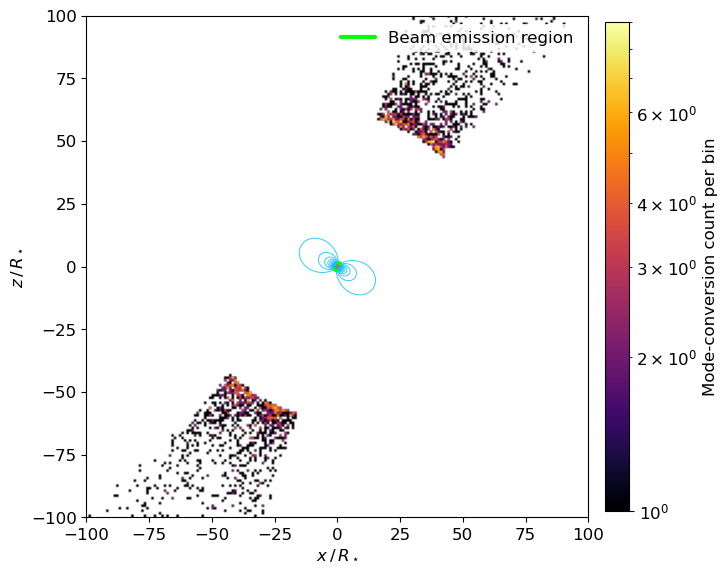

In [16]:
"""
Heat map of O<->X mode-conversion locations in the pulsar magnetosphere,
with the tilted dipole's field lines, the beam emission region, and the
star overlaid.

This is a PROJECTION: each 3D conversion location (x,y,z) [already in units
of R_star -- the ray tracer's native units, see pulsar_ox_raytracer.py's
module docstring, so NO further unit conversion is applied here] is reduced
to 2D by collapsing the azimuthal (helical) direction while preserving the
exact 3D radius r and lab-frame polar angle theta (measured from the
ROTATION axis z, not the tilted magnetic axis):

    r      = sqrt(x^2 + y^2 + z^2)
    theta  = arccos(z / r)
    x_proj = sign(x) * r * sin(theta)   [[ = sign(x) * sqrt(x^2 + y^2) ]]
    z_proj = r * cos(theta)             [[ = z, unchanged ]]

Two points at the same (r, theta) but different azimuth phi collapse onto
the same projected point (up to the sign-of-x convention above) -- this is
the "disregards the helical direction" projection, used because it keeps
r and theta exact rather than simply dropping y.

The tilted dipole's magnetic axis mhat = [sin(chi), 0, cos(chi)] always has
zero y-component in this model, so it lies EXACTLY in the lab-frame x-z
plane for any inclination chi. That means both the field-line contour
background AND the beam emission region below can be computed directly in
this plane -- not an approximation, but an exact slice through the plane
containing the magnetic axis.

Beam emission region: rays are launched at radius r_em (NOT the stellar
surface r=1) within a cone of half-angle cap_deg around the magnetic axis,
both poles (see launch_field_aligned). Since the magnetic axis lies exactly
in this x-z plane, each pole's emission region is simply the arc at radius
r_em spanning +-cap_deg around that pole's direction -- drawn directly, no
sampling needed.
"""

import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')   # avoids "unable to
    # lock file" errors on network/cluster filesystems where HDF5's native
    # file locking isn't properly supported -- must be set before h5py is
    # imported, since the underlying HDF5 library reads it at load time.

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# =====================================================================
# Launch-geometry parameters -- these must match the actual cluster run
# that produced conv_log_path. Names mirror the CLI tool's own argument
# names 1:1 (--chi-deg, --cap-deg, --r-em) so you can copy values directly
# from the run command you used, e.g.
#   python pulsar_ox_raytracer.py --chi-deg 30.0 --cap-deg 20.0 --r-em 1.5 ...
# gives chi_deg=30.0, cap_deg=20.0, r_em=1.5 below.
# =====================================================================

conv_log_path = '/dartfs-hpc/rc/home/7/f007gj7/radio_ray_tracing/conv_locations_test.h5'
chi_deg = 30.0    # magnetic obliquity [deg]   <-> CLI --chi-deg
cap_deg = 10.0    # footpoint half-angle [deg] <-> CLI --cap-deg
r_em    = 1.5     # emission radius [R_star]   <-> CLI --r-em

# =====================================================================
# Other plot parameters
# =====================================================================

box          = 100.0    # plot domain: x/R*, z/R* both range over [-box, box]
nbins        = 200     # heat map resolution (nbins x nbins over the box)
n_fieldlines = 14      # number of field-line contour levels to draw

# ---- rendering: fonts, resolution, sizes -----------------------------
figsize       = (7, 7)   # inches
dpi           = 100      # on-screen figure resolution
save_dpi      = 100      # saved-file resolution
fontsize_axis = 12       # axis labels (x/R*, z/R*)
fontsize_tick = 12       # tick labels
fontsize_legend = 12
fontsize_cbar_label = 12
fontsize_cbar_tick  = 12
fieldline_width = 0.7
fieldline_color = 'deepskyblue'
beam_color      = 'lime'
beam_linewidth  = 3
heatmap_cmap  = 'inferno'

# =====================================================================
# Load conversion locations (already in units of R_star -- no conversion)
# =====================================================================

with h5py.File(conv_log_path, 'r') as f:
    conv_x = f['conv_x'][:]   # shape (N, 3); columns are x, y, z in R_star
x, y, z = conv_x[:, 0], conv_x[:, 1], conv_x[:, 2]


def project(x, y, z):
    """r,theta-preserving projection onto (x_proj, z_proj); see module docstring."""
    r      = np.sqrt(x**2 + y**2 + z**2)
    theta  = np.arccos(np.clip(z / r, -1.0, 1.0))
    x_proj = np.sign(x) * r * np.sin(theta)
    z_proj = z.copy()
    return x_proj, z_proj


x_proj, z_proj = project(x, y, z)

# =====================================================================
# Figure / rendering setup
# =====================================================================

plt.rcParams['font.size'] = fontsize_tick

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

# =====================================================================
# Heat map of conversion locations
# =====================================================================

h_edges = np.linspace(-box, box, nbins + 1)
H, xedges, zedges = np.histogram2d(x_proj, z_proj, bins=[h_edges, h_edges])
im = ax.imshow(H.T, origin='lower', extent=[-box, box, -box, box],
               cmap=heatmap_cmap, aspect='equal',
               norm=plt.matplotlib.colors.LogNorm(vmin=max(H[H > 0].min(), 1), vmax=H.max()))
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label('Mode-conversion count per bin', fontsize=fontsize_cbar_label)
cbar.ax.tick_params(labelsize=fontsize_cbar_tick)

# =====================================================================
# Tilted-dipole field-line contours (flux function), exact slice at y=0
# =====================================================================

chi = np.deg2rad(chi_deg)
mhat_xz = np.array([np.sin(chi), np.cos(chi)])   # mhat has zero y-component;
                                                  # this is its (x,z) part exactly

xg = np.linspace(-box, box, 500)
zg = np.linspace(-box, box, 500)
Xg, Zg = np.meshgrid(xg, zg)
Rg = np.sqrt(Xg**2 + Zg**2)
with np.errstate(invalid='ignore', divide='ignore'):
    cos_theta_mag = (Xg * mhat_xz[0] + Zg * mhat_xz[1]) / Rg
    sin2_theta_mag = 1.0 - cos_theta_mag**2
    # flux function for THIS code's dipole normalization (|B|=1 at the pole,
    # r=1): Psi = 0.5 * sin^2(theta_mag) / r -- see module docstring for the
    # B_r = cos(theta_mag)/r^3 derivation this matches.
    Psi = 0.5 * sin2_theta_mag / Rg
Psi[Rg < 1.0] = np.nan   # do not draw field lines inside the star

ax.contour(Xg, Zg, Psi, levels=n_fieldlines, colors=fieldline_color,
           linewidths=fieldline_width, alpha=0.8)

# =====================================================================
# Beam emission region: arc at radius r_em, +-cap_deg around each pole's
# direction (exact, since the magnetic axis lies in this plane -- no
# sampling needed)
# =====================================================================

cap_rad = np.deg2rad(cap_deg)
for pole_angle in (chi, chi + np.pi):
    th = np.linspace(pole_angle - cap_rad, pole_angle + cap_rad, 100)
    ax.plot(r_em*np.sin(th), r_em*np.cos(th), color=beam_color, lw=beam_linewidth,
            solid_capstyle='round', zorder=4,
            label='Beam emission region' if pole_angle == chi else None)

# =====================================================================
# The star itself: gray filled disk, no border, r=1 (R_star)
# =====================================================================

ax.add_patch(Circle((0, 0), 1.0, facecolor='gray', edgecolor='none', zorder=5))

# =====================================================================
# Cosmetics
# =====================================================================

ax.set_xlim(-box, box)
ax.set_ylim(-box, box)
ax.set_xlabel(r'$x\,/\,R_\star$', fontsize=fontsize_axis)
ax.set_ylabel(r'$z\,/\,R_\star$', fontsize=fontsize_axis)
ax.tick_params(labelsize=fontsize_tick)
ax.legend(loc='upper right', fontsize=fontsize_legend, framealpha=0.85, edgecolor='none')

plt.show()

# fig.savefig('/home/claude/conv_heatmap.png', dpi=save_dpi, bbox_inches='tight')
# print('saved')